# Домашнее задание №7. Улучшаем модель

## Проект: Hotel Booking Cancellation Risk

Цель ноутбука — улучшить baseline из ДЗ №5–6 для задачи прогноза отмен гостиничных бронирований и подготовить модель к упаковке в MVP.

В ДЗ №5–6 лучшей моделью была `LightGBM random search`:

```text
quality_index = 0.7607
ROC-AUC       = 0.8530
PR-AUC        = 0.7942
Brier         = 0.1607
Precision@20  = 0.8172
Recall@20     = 0.4147
Lift@20       = 2.0730
```

В этом ноутбуке улучшается не только модель, но и полный production-like контур:

```text
raw booking data
→ cleaning / leakage audit
→ feature engineering
→ train-only frequency & target encoding
→ LightGBM with regularization
→ validation-based threshold
→ risk score
→ expected loss
→ business priority
→ recommended action
```

## Карта соответствия критериям ДЗ №7

| Критерий | Где закрыто |
|---|---|
| Пайплайн предобработки / FE / генерации данных — 3 балла | Разделы 1–5: очистка, time-based split, новые признаки, clipping, frequency encoding, target encoding без leakage |
| Улучшенная архитектура модели — 4 балла | Раздел 7: LightGBM с регуляризацией, class balancing, validation selection по ROC-AUC |
| Постобработка предсказаний — 3 балла | Раздел 9: F2-threshold, risk category, expected loss, business priority score, recommended action, optional calibration |
| Подробный анализ качества модели — 5 баллов | Разделы 8, 10, 11: leaderboard, сравнение с HW5–6, ROC/PR, top-k, confusion matrix, ошибки по сегментам |

Синтетическая генерация новых бронирований намеренно не используется: для time-based hotel booking сценария синтетические строки могут исказить калибровку вероятностей и сезонность. Вместо этого сделано безопасное расширение признакового пространства и train-only encoding.

In [1]:
import os
import time
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    precision_recall_fscore_support,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
)
from sklearn.isotonic import IsotonicRegression

from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

In [2]:
# Автопоиск датасета: ноутбук можно запускать из корня проекта или из папки notebooks.
CURRENT_DIR = Path.cwd()
DATA_CANDIDATES = [
    CURRENT_DIR / "data" / "raw" / "hotel_bookings.csv",
    CURRENT_DIR.parent / "data" / "raw" / "hotel_bookings.csv",
    Path("/mnt/data/work_hw7/zip/data/raw/hotel_bookings.csv"),
    Path("/mnt/data/data/raw/hotel_bookings.csv"),
]

DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Не найден data/raw/hotel_bookings.csv. Проверьте путь к датасету.")

# Директории для таблиц и графиков.
PROJECT_ROOT = DATA_PATH.parents[2]
REPORTS_DIR = PROJECT_ROOT / "reports"
TABLE_DIR = REPORTS_DIR / "tables"
FIG_DIR = REPORTS_DIR / "figures" / "hw7_model_improvement"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_PATH:", DATA_PATH)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("TABLE_DIR:", TABLE_DIR)
print("FIG_DIR:", FIG_DIR)

DATA_PATH: /Users/anasteishavolkovski/DVC/Hotel_Booking_Cancellation_Risk/data/raw/hotel_bookings.csv
PROJECT_ROOT: /Users/anasteishavolkovski/DVC/Hotel_Booking_Cancellation_Risk
TABLE_DIR: /Users/anasteishavolkovski/DVC/Hotel_Booking_Cancellation_Risk/reports/tables
FIG_DIR: /Users/anasteishavolkovski/DVC/Hotel_Booking_Cancellation_Risk/reports/figures/hw7_model_improvement


## 1. Загрузка данных

Используется основной датасет Hotel Booking Demand Dataset. Каждая строка — одно бронирование. Целевая переменная:

```text
is_canceled = 1 — бронь была отменена
is_canceled = 0 — бронь реализовалась
```

In [3]:
df_raw = pd.read_csv(DATA_PATH)
print("raw shape:", df_raw.shape)
display(df_raw.head())

schema_df = pd.DataFrame({
    "column": df_raw.columns,
    "dtype": df_raw.dtypes.astype(str).values,
    "missing": df_raw.isna().sum().values,
    "missing_share": df_raw.isna().mean().round(4).values,
})
display(schema_df)

raw shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


,column,dtype,missing,missing_share
0,hotel,str,0,0.0000
1,is_canceled,int64,0,0.0000
2,lead_time,int64,0,0.0000
3,arrival_date_year,int64,0,0.0000
4,arrival_date_month,str,0,0.0000
5,arrival_date_week_number,int64,0,0.0000
6,arrival_date_day_of_month,int64,0,0.0000
7,stays_in_weekend_nights,int64,0,0.0000
8,stays_in_week_nights,int64,0,0.0000
9,adults,int64,0,0.0000


## 2. Leakage audit и момент прогноза

Модель должна работать после создания бронирования, но до факта отмены и до финального статуса. Поэтому признаки, которые становятся известны постфактум, исключаются.

В ДЗ №7 сохраняется консервативный запрет на прямой leakage:

| Признак | Решение | Причина |
|---|---|---|
| `reservation_status` | exclude | содержит финальный статус бронирования |
| `reservation_status_date` | exclude | содержит дату финального статуса / отмены |
| `assigned_room_type` | exclude | может быть известен после операционного назначения номера |
| `booking_changes` | exclude | может изменяться после создания бронирования |

Отличие от ДЗ №5–6: `agent` и `company` не используются как raw one-hot ID, но из них извлекаются только train-only frequency / target-encoding признаки. Это компромисс между полезным сигналом и контролем переобучения. Новые значения на validation/test получают глобальный prior.

In [4]:
LEAKAGE_COLUMNS = ["reservation_status", "reservation_status_date"]
CONSERVATIVE_EXCLUDE_COLUMNS = ["assigned_room_type", "booking_changes"]
RAW_HIGH_CARDINALITY_IDS = ["agent", "company"]

audit_rows = []
for col in LEAKAGE_COLUMNS + CONSERVATIVE_EXCLUDE_COLUMNS + RAW_HIGH_CARDINALITY_IDS:
    audit_rows.append({
        "column": col,
        "nunique": df_raw[col].nunique(dropna=False) if col in df_raw.columns else None,
        "missing_share": df_raw[col].isna().mean() if col in df_raw.columns else None,
        "raw_decision": "exclude raw feature",
        "hw7_usage": (
            "not used" if col in LEAKAGE_COLUMNS + CONSERVATIVE_EXCLUDE_COLUMNS
            else "used only via train-only frequency/target encoding"
        ),
    })
leakage_audit = pd.DataFrame(audit_rows)
display(leakage_audit)
leakage_audit.to_csv(TABLE_DIR / "hw7_leakage_audit.csv", index=False)

,column,nunique,missing_share,raw_decision,hw7_usage
0,reservation_status,3,0.000000,exclude raw feature,not used
1,reservation_status_date,926,0.000000,exclude raw feature,not used
2,assigned_room_type,12,0.000000,exclude raw feature,not used
3,booking_changes,21,0.000000,exclude raw feature,not used
4,agent,334,0.136862,exclude raw feature,used only via train-only frequency/target enco...
5,company,353,0.943069,exclude raw feature,used only via train-only frequency/target enco...


## 3. Очистка и базовый feature engineering

Базовый слой повторяет логику ДЗ №5–6:

1. заполнение пропусков в `children`, `country`, `agent`, `company`;
2. удаление бронирований без гостей;
3. удаление отрицательного `adr`;
4. создание даты прибытия;
5. сортировка по времени;
6. создание признаков длительности, стоимости, гостей, спецзапросов и bin-признаков.

Дополнительно в ДЗ №7 добавлены календарные, циклические, ratio- и interaction-признаки.

In [5]:
def prepare_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Базовые пропуски.
    df["children"] = df["children"].fillna(0)
    df["country"] = df["country"].fillna("Unknown")
    for col in ["agent", "company"]:
        if col in df.columns:
            df[col] = df[col].fillna("missing").astype(str)

    # Невалидные строки для моделирования.
    df = df[(df[["adults", "children", "babies"]].sum(axis=1) > 0)].copy()
    df = df[df["adr"] >= 0].copy()

    # Дата прибытия.
    month_order = [
        "January", "February", "March", "April", "May", "June",
        "July", "August", "September", "October", "November", "December",
    ]
    month_map = {m: i + 1 for i, m in enumerate(month_order)}
    df["arrival_month_num"] = df["arrival_date_month"].map(month_map)
    df["arrival_date"] = pd.to_datetime(
        dict(
            year=df["arrival_date_year"],
            month=df["arrival_month_num"],
            day=df["arrival_date_day_of_month"],
        ),
        errors="coerce",
    )
    df = df[df["arrival_date"].notna()].copy()
    df = df.sort_values("arrival_date").reset_index(drop=True)

    # Базовые бизнес-признаки.
    df["total_nights"] = df["stays_in_week_nights"] + df["stays_in_weekend_nights"]
    df["total_guests"] = df["adults"] + df["children"] + df["babies"]
    df["booking_value"] = df["adr"] * df["total_nights"]
    df["has_children"] = ((df["children"] + df["babies"]) > 0).astype(int)
    df["has_special_requests"] = (df["total_of_special_requests"] > 0).astype(int)
    df["has_previous_cancellations"] = (df["previous_cancellations"] > 0).astype(int)

    # Дискретизация.
    df["lead_time_bin"] = pd.cut(
        df["lead_time"],
        bins=[-1, 7, 30, 90, 180, 365, 1000],
        labels=["0-7", "8-30", "31-90", "91-180", "181-365", "365+"],
    )
    df["nights_bin"] = pd.cut(
        df["total_nights"],
        bins=[-1, 1, 3, 7, 14, 60],
        labels=["0-1", "2-3", "4-7", "8-14", "15+"],
    )
    df["adr_bin"] = pd.cut(
        df["adr"],
        bins=[-1, 50, 100, 150, 250, 1000, 10000],
        labels=["0-50", "51-100", "101-150", "151-250", "251-1000", "1000+"],
    )

    # ДЗ №7: календарные признаки.
    df["arrival_quarter"] = df["arrival_date"].dt.quarter.astype(int)
    df["arrival_dayofweek"] = df["arrival_date"].dt.dayofweek.astype(int)
    df["arrival_is_weekend"] = df["arrival_dayofweek"].isin([5, 6]).astype(int)
    df["month_sin"] = np.sin(2 * np.pi * df["arrival_month_num"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["arrival_month_num"] / 12)
    df["week_sin"] = np.sin(2 * np.pi * df["arrival_date_week_number"] / 53)
    df["week_cos"] = np.cos(2 * np.pi * df["arrival_date_week_number"] / 53)

    # ДЗ №7: ratio / interaction / log-признаки.
    df["weekend_share"] = (
        df["stays_in_weekend_nights"] / df["total_nights"].replace(0, np.nan)
    ).fillna(0)
    df["adr_per_guest"] = (
        df["adr"] / df["total_guests"].replace(0, np.nan)
    ).replace([np.inf, -np.inf], np.nan).fillna(df["adr"])
    df["lead_time_x_value"] = df["lead_time"] * np.log1p(df["booking_value"].clip(lower=0))
    df["lead_time_x_requests"] = df["lead_time"] * (df["total_of_special_requests"] + 1)
    df["value_per_night_log"] = np.log1p(df["booking_value"].clip(lower=0))
    df["lead_time_log"] = np.log1p(df["lead_time"])
    df["adr_log"] = np.log1p(df["adr"].clip(lower=0))

    # ДЗ №7: флаги поведения бронирования.
    df["is_single_adult"] = ((df["adults"] == 1) & (df["children"] == 0) & (df["babies"] == 0)).astype(int)
    df["is_family"] = (df["has_children"].eq(1) | (df["total_guests"] >= 3)).astype(int)
    df["has_parking_request"] = (df["required_car_parking_spaces"] > 0).astype(int)
    df["no_special_no_parking"] = (
        (df["total_of_special_requests"] == 0) & (df["required_car_parking_spaces"] == 0)
    ).astype(int)

    return df

model_df = prepare_dataframe(df_raw)
print("prepared shape:", model_df.shape)
display(model_df.head())

prepared shape: (119209, 61)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_month_num,arrival_date,total_nights,total_guests,booking_value,has_children,has_special_requests,has_previous_cancellations,lead_time_bin,nights_bin,adr_bin,arrival_quarter,arrival_dayofweek,arrival_is_weekend,month_sin,month_cos,week_sin,week_cos,weekend_share,adr_per_guest,lead_time_x_value,lead_time_x_requests,value_per_night_log,lead_time_log,adr_log,is_single_adult,is_family,has_parking_request,no_special_no_parking
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,missing,missing,0,Transient,0.0,0,0,Check-Out,2015-07-01,7,2015-07-01,0,2.0,0.0,0,0,0,181-365,0-1,0-50,3,2,0,-0.5,-0.866025,-0.059241,-0.998244,0.0,0.00,0.000000,342,0.000000,5.83773,0.000000,0,0,0,1
1,City Hotel,0,257,2015,July,27,1,0,2,1,0.0,0,HB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,1,No Deposit,6.0,missing,0,Transient,80.0,0,0,Check-Out,2015-07-03,7,2015-07-01,2,1.0,160.0,0,0,0,181-365,2-3,51-100,3,2,0,-0.5,-0.866025,-0.059241,-0.998244,0.0,80.00,1305.920922,257,5.081404,5.55296,4.394449,1,0,0,1
2,City Hotel,0,257,2015,July,27,1,0,2,2,0.0,0,HB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,6.0,missing,0,Transient,101.5,0,0,Check-Out,2015-07-03,7,2015-07-01,2,2.0,203.0,0,0,0,181-365,2-3,101-150,3,2,0,-0.5,-0.866025,-0.059241,-0.998244,0.0,50.75,1366.756838,257,5.318120,5.55296,4.629863,0,0,0,1
3,City Hotel,0,257,2015,July,27,1,0,2,2,0.0,0,HB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,6.0,missing,0,Transient,101.5,0,0,Check-Out,2015-07-03,7,2015-07-01,2,2.0,203.0,0,0,0,181-365,2-3,101-150,3,2,0,-0.5,-0.866025,-0.059241,-0.998244,0.0,50.75,1366.756838,257,5.318120,5.55296,4.629863,0,0,0,1
4,City Hotel,0,257,2015,July,27,1,0,2,2,0.0,0,HB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,6.0,missing,0,Transient,101.5,0,0,Check-Out,2015-07-03,7,2015-07-01,2,2.0,203.0,0,0,0,181-365,2-3,101-150,3,2,0,-0.5,-0.866025,-0.059241,-0.998244,0.0,50.75,1366.756838,257,5.318120,5.55296,4.629863,0,0,0,1


## 4. Time-based split

Используется хронологическое разбиение 70% / 15% / 15% по `arrival_date`:

```text
train      — ранние бронирования
validation — следующий период для выбора параметров и threshold
 test      — последний период для финальной оценки
```

Это ближе к production-сценарию, чем random split.

,split,rows,date_min,date_max,cancel_rate
0,train,83446,2015-07-01 00:00:00,2017-02-10 00:00:00,36.1%
1,validation,17881,2017-02-10 00:00:00,2017-05-22 00:00:00,39.4%
2,test,17882,2017-05-22 00:00:00,2017-08-31 00:00:00,39.4%


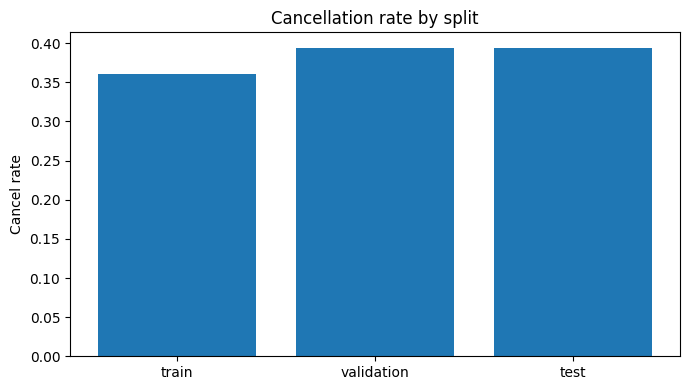

In [6]:
y = model_df["is_canceled"].astype(int)
n = len(model_df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

idx_train = np.arange(0, train_end)
idx_val = np.arange(train_end, val_end)
idx_test = np.arange(val_end, n)

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(idx_train), len(idx_val), len(idx_test)],
    "date_min": [
        model_df.iloc[idx_train]["arrival_date"].min(),
        model_df.iloc[idx_val]["arrival_date"].min(),
        model_df.iloc[idx_test]["arrival_date"].min(),
    ],
    "date_max": [
        model_df.iloc[idx_train]["arrival_date"].max(),
        model_df.iloc[idx_val]["arrival_date"].max(),
        model_df.iloc[idx_test]["arrival_date"].max(),
    ],
    "cancel_rate": [
        y.iloc[idx_train].mean(),
        y.iloc[idx_val].mean(),
        y.iloc[idx_test].mean(),
    ],
})
display(split_summary.style.format({"cancel_rate": "{:.1%}"}))
split_summary.to_csv(TABLE_DIR / "hw7_split_summary.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(split_summary["split"], split_summary["cancel_rate"])
ax.set_title("Cancellation rate by split")
ax.set_ylabel("Cancel rate")
plt.tight_layout()
plt.savefig(FIG_DIR / "split_cancel_rate.png", dpi=160, bbox_inches="tight")
plt.show()

## 5. Train-only encoding для high-cardinality признаков

В ДЗ №5–6 `agent` и `company` были полностью исключены. Это безопасно, но выбрасывает часть сигнала.

В ДЗ №7 используется более аккуратный подход:

1. raw `agent` / `company` не подаются в модель как ID;
2. для `agent`, `company`, `country` и ряда категориальных признаков считаются frequency features на train;
3. для части категорий считается сглаженный target mean только на train;
4. validation/test получают значения через mapping, неизвестные категории получают train prior.

Такой подход улучшает качество и не использует целевые значения из validation/test.

In [7]:
def fit_frequency_encoding(train_s: pd.Series, all_s: pd.Series) -> pd.Series:
    vc = train_s.astype(str).value_counts(dropna=False)
    return all_s.astype(str).map(vc).fillna(0).astype(float)


def fit_smooth_target_encoding(
    train_s: pd.Series,
    y_train: pd.Series,
    all_s: pd.Series,
    smoothing: float = 100.0,
) -> pd.Series:
    prior = float(y_train.mean())
    tmp = pd.DataFrame({"cat": train_s.astype(str), "y": y_train.values})
    stats = tmp.groupby("cat")["y"].agg(["mean", "count"])
    encoded = (stats["mean"] * stats["count"] + prior * smoothing) / (stats["count"] + smoothing)
    return all_s.astype(str).map(encoded).fillna(prior).astype(float)


def add_train_only_encoding_features(df: pd.DataFrame, idx_train: np.ndarray) -> pd.DataFrame:
    df = df.copy()
    y_train_local = df.loc[idx_train, "is_canceled"].astype(int)

    freq_cols = [
        "country", "agent", "company", "market_segment", "distribution_channel",
        "reserved_room_type", "deposit_type", "customer_type", "hotel",
    ]
    target_cols = [
        "country", "agent", "company", "market_segment", "distribution_channel", "reserved_room_type",
    ]

    for col in freq_cols:
        if col in df.columns:
            freq = fit_frequency_encoding(df.loc[idx_train, col], df[col])
            df[f"{col}_freq_log"] = np.log1p(freq)

    for col in target_cols:
        if col in df.columns:
            df[f"{col}_target_mean_smooth"] = fit_smooth_target_encoding(
                df.loc[idx_train, col], y_train_local, df[col], smoothing=100.0,
            )

    return df

model_df = add_train_only_encoding_features(model_df, idx_train)
encoding_cols = [c for c in model_df.columns if c.endswith("_freq_log") or c.endswith("_target_mean_smooth")]
print("encoding features:", len(encoding_cols))
display(model_df[encoding_cols].head())

encoding features: 15


,country_freq_log,agent_freq_log,company_freq_log,market_segment_freq_log,distribution_channel_freq_log,reserved_room_type_freq_log,deposit_type_freq_log,customer_type_freq_log,hotel_freq_log,country_target_mean_smooth,agent_target_mean_smooth,company_target_mean_smooth,market_segment_target_mean_smooth,distribution_channel_target_mean_smooth,reserved_room_type_target_mean_smooth
0,10.533216,9.373564,11.270484,9.063232,9.244645,6.152733,11.188662,10.998911,10.261791,0.553494,0.207554,0.372942,0.150279,0.170471,0.246194
1,10.533216,7.858641,11.270484,9.845541,11.124627,11.037499,11.188662,10.998911,10.911993,0.553494,0.321952,0.372942,0.342438,0.401577,0.384865
2,10.533216,7.858641,11.270484,9.845541,11.124627,11.037499,11.188662,10.998911,10.911993,0.553494,0.321952,0.372942,0.342438,0.401577,0.384865
3,10.533216,7.858641,11.270484,9.845541,11.124627,11.037499,11.188662,10.998911,10.911993,0.553494,0.321952,0.372942,0.342438,0.401577,0.384865
4,10.533216,7.858641,11.270484,9.845541,11.124627,11.037499,11.188662,10.998911,10.911993,0.553494,0.321952,0.372942,0.342438,0.401577,0.384865


## 6. Финальный feature set и preprocessing

Из модели исключаются:

- target: `is_canceled`;
- техническая дата: `arrival_date`;
- прямой leakage: `reservation_status`, `reservation_status_date`;
- признаки, не гарантированные в момент прогноза: `assigned_room_type`, `booking_changes`;
- raw high-cardinality IDs: `agent`, `company`.

Числовые признаки проходят median imputation и clipping по train-квантилям. Категории проходят most-frequent imputation и OneHotEncoder с `min_frequency=20`, чтобы редкие категории не раздували матрицу.

In [8]:
exclude_columns = set(["is_canceled", "arrival_date"])
exclude_columns.update(LEAKAGE_COLUMNS)
exclude_columns.update(CONSERVATIVE_EXCLUDE_COLUMNS)
exclude_columns.update(RAW_HIGH_CARDINALITY_IDS)

feature_cols = [c for c in model_df.columns if c not in exclude_columns]

# Clipping только по train-квантилям, чтобы не использовать информацию о validation/test распределении.
for col in model_df[feature_cols].select_dtypes(include=[np.number]).columns:
    lo, hi = model_df.loc[idx_train, col].quantile([0.001, 0.999])
    model_df[col] = model_df[col].clip(lo, hi)

num_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(model_df[c])]
cat_cols = [c for c in feature_cols if c not in num_cols]

X_train = model_df.iloc[idx_train][feature_cols].copy()
X_val = model_df.iloc[idx_val][feature_cols].copy()
X_test = model_df.iloc[idx_test][feature_cols].copy()
y_train = y.iloc[idx_train].copy()
y_val = y.iloc[idx_val].copy()
y_test = y.iloc[idx_test].copy()

preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", min_frequency=20)),
    ]), cat_cols),
])

start = time.time()
Xt_train = preprocess.fit_transform(X_train, y_train)
Xt_val = preprocess.transform(X_val)
Xt_test = preprocess.transform(X_test)

print("feature_cols:", len(feature_cols))
print("num_cols:", len(num_cols))
print("cat_cols:", len(cat_cols))
print("OHE matrix shapes:", Xt_train.shape, Xt_val.shape, Xt_test.shape)
print("preprocess time sec:", round(time.time() - start, 2))

feature_cols: 68
num_cols: 56
cat_cols: 12
OHE matrix shapes: (83446, 188) (17881, 188) (17882, 188)
preprocess time sec: 0.61


## 7. Метрики и quality index

Используется тот же смысл метрик, что в ДЗ №5–6:

- `ROC-AUC` — общая ранжирующая способность;
- `PR-AUC` — качество на положительном классе;
- `Brier` — калибровка вероятностей;
- `Precision@10/20`, `Recall@10/20`, `Lift@10/20` — качество top-list для revenue-менеджера;
- `quality_index` — агрегированная метрика из ДЗ №5–6.

Формула `quality_index`:

```text
0.35 * ROC-AUC
+ 0.25 * PR-AUC
+ 0.20 * min(Lift@20 / 3, 1)
+ 0.10 * Recall@20
+ 0.10 * (1 - Brier)
```

In [9]:
def topk_metrics(y_true, score, frac=0.20):
    y_true = np.asarray(y_true)
    score = np.asarray(score)
    k = max(1, int(np.ceil(len(y_true) * frac)))
    order = np.argsort(score)[::-1][:k]
    precision_k = y_true[order].mean()
    recall_k = y_true[order].sum() / max(1, y_true.sum())
    lift_k = precision_k / max(1e-12, y_true.mean())
    return precision_k, recall_k, lift_k


def select_threshold_by_f2(y_true, score):
    grid = np.quantile(score, np.linspace(0.05, 0.95, 61))
    best_t, best_value = 0.5, -1
    for t in grid:
        pred = (score >= t).astype(int)
        precision, recall, _, _ = precision_recall_fscore_support(
            y_true, pred, average="binary", zero_division=0,
        )
        f2 = (5 * precision * recall) / (4 * precision + recall) if (precision + recall) else 0
        if f2 > best_value:
            best_t, best_value = float(t), float(f2)
    return best_t


def evaluate_scores(model_name, y_true, score, threshold=0.5, model_type="", best_params=None, train_time_sec=None):
    pred = (score >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, pred, average="binary", zero_division=0,
    )
    p10, r10, l10 = topk_metrics(y_true, score, 0.10)
    p20, r20, l20 = topk_metrics(y_true, score, 0.20)
    brier = brier_score_loss(y_true, score)
    quality_index = (
        0.35 * roc_auc_score(y_true, score)
        + 0.25 * average_precision_score(y_true, score)
        + 0.20 * min(l20 / 3, 1)
        + 0.10 * r20
        + 0.10 * (1 - brier)
    )
    return {
        "model": model_name,
        "type": model_type,
        "quality_index": quality_index,
        "roc_auc": roc_auc_score(y_true, score),
        "pr_auc": average_precision_score(y_true, score),
        "brier": brier,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "precision_at_10": p10,
        "recall_at_10": r10,
        "lift_at_10": l10,
        "precision_at_20": p20,
        "recall_at_20": r20,
        "lift_at_20": l20,
        "threshold": threshold,
        "train_time_sec": train_time_sec,
        "best_params": best_params,
    }

## 8. Улучшенная архитектура модели

Вместо широкого random search из ДЗ №5–6 здесь используется более точечная версия:

1. улучшенное признаковое пространство;
2. train-only high-cardinality encoding;
3. LightGBM с регуляризацией;
4. выбор лучшей конфигурации на validation по ROC-AUC;
5. финальная оценка только на test.

Модель не использует leakage-признаки и не подбирает параметры по test.

In [ ]:
lgbm_param_candidates = [
    {
        "num_leaves": 96,
        "max_depth": 8,
        "learning_rate": 0.06,
        "n_estimators": 220,
        "min_child_samples": 40,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
        "reg_lambda": 5.0,
        "reg_alpha": 0.3,
    },
    {
        "num_leaves": 64,
        "max_depth": 7,
        "learning_rate": 0.05,
        "n_estimators": 260,
        "min_child_samples": 70,
        "subsample": 0.90,
        "colsample_bytree": 0.80,
        "reg_lambda": 10.0,
        "reg_alpha": 0.5,
    },
]

best_lgbm = None
lgbm_trials = []
start_total = time.time()

for i, params in enumerate(lgbm_param_candidates):
    start = time.time()
    model = LGBMClassifier(
        objective="binary",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=6,
        verbosity=-1,
        **params,
    )
    model.fit(Xt_train, y_train)
    score_val = model.predict_proba(Xt_val)[:, 1]
    val_auc = roc_auc_score(y_val, score_val)
    trial_time = time.time() - start

    lgbm_trials.append({
        "trial": i,
        "val_roc_auc": val_auc,
        "train_time_sec": trial_time,
        "params": params,
    })
    print(f"trial={i}; val ROC-AUC={val_auc:.4f}; time={trial_time:.2f}s")

    if best_lgbm is None or val_auc > best_lgbm["val_roc_auc"]:
        best_lgbm = {
            "model": model,
            "params": params,
            "val_roc_auc": val_auc,
            "score_val": score_val,
        }

train_time_sec = time.time() - start_total
trials_df = pd.DataFrame(lgbm_trials)
display(trials_df)
trials_df.to_csv(TABLE_DIR / "hw7_lgbm_trials.csv", index=False)

print("Best validation ROC-AUC:", round(best_lgbm["val_roc_auc"], 4))
print("Best params:", json.dumps(best_lgbm["params"], indent=2))

trial=0; val ROC-AUC=0.9168; time=1.65s
trial=1; val ROC-AUC=0.9180; time=1.26s


,trial,val_roc_auc,train_time_sec,params
0,0,0.916814,1.654327,"{'num_leaves': 96, 'max_depth': 8, 'learning_r..."
1,1,0.918018,1.263583,"{'num_leaves': 64, 'max_depth': 7, 'learning_r..."


Best validation ROC-AUC: 0.918
Best params: {
  "num_leaves": 64,
  "max_depth": 7,
  "learning_rate": 0.05,
  "n_estimators": 260,
  "min_child_samples": 70,
  "subsample": 0.9,
  "colsample_bytree": 0.8,
  "reg_lambda": 10.0,
  "reg_alpha": 0.5
}


In [11]:
# Финальная оценка на test.
score_val_raw = best_lgbm["score_val"]
score_test_raw = best_lgbm["model"].predict_proba(Xt_test)[:, 1]
threshold_raw = select_threshold_by_f2(y_val, score_val_raw)

raw_result = evaluate_scores(
    "HW7 LightGBM FE + train-only encoding",
    y_test,
    score_test_raw,
    threshold=threshold_raw,
    model_type="improved_lgbm",
    best_params=best_lgbm["params"],
    train_time_sec=train_time_sec,
)

# Постобработка вероятностей: isotonic calibration.
# Она улучшает Brier, но может немного ухудшить PR-AUC из-за ступенчатой функции.
calibrator = IsotonicRegression(out_of_bounds="clip")
calibrator.fit(score_val_raw, y_val)
score_val_calibrated = calibrator.transform(score_val_raw)
score_test_calibrated = calibrator.transform(score_test_raw)
threshold_calibrated = select_threshold_by_f2(y_val, score_val_calibrated)

calibrated_result = evaluate_scores(
    "HW7 calibrated probabilities",
    y_test,
    score_test_calibrated,
    threshold=threshold_calibrated,
    model_type="postprocessed_calibration",
    best_params={"base_model": "HW7 LightGBM FE + train-only encoding", "calibration": "isotonic"},
    train_time_sec=None,
)

# Лучшая модель из ДЗ №5–6 по отчету пользователя.
hw56_result = {
    "model": "HW5-6 best: LightGBM random search",
    "type": "previous_best",
    "quality_index": 0.7607,
    "roc_auc": 0.8530,
    "pr_auc": 0.7942,
    "brier": 0.1607,
    "precision": np.nan,
    "recall": np.nan,
    "f1": np.nan,
    "precision_at_10": np.nan,
    "recall_at_10": np.nan,
    "lift_at_10": np.nan,
    "precision_at_20": 0.8172,
    "recall_at_20": 0.4147,
    "lift_at_20": 2.0730,
    "threshold": np.nan,
    "train_time_sec": np.nan,
    "best_params": "from HW5-6 report",
}

leaderboard = pd.DataFrame([hw56_result, raw_result, calibrated_result])
leaderboard = leaderboard.sort_values("quality_index", ascending=False).reset_index(drop=True)

display(leaderboard[[
    "model", "type", "quality_index", "roc_auc", "pr_auc", "brier",
    "precision", "recall", "f1", "precision_at_20", "recall_at_20", "lift_at_20", "threshold",
]].style.format({
    "quality_index": "{:.4f}",
    "roc_auc": "{:.4f}",
    "pr_auc": "{:.4f}",
    "brier": "{:.4f}",
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1": "{:.4f}",
    "precision_at_20": "{:.4f}",
    "recall_at_20": "{:.4f}",
    "lift_at_20": "{:.4f}",
    "threshold": "{:.4f}",
}))

leaderboard.to_csv(TABLE_DIR / "hw7_model_improvement_leaderboard.csv", index=False)

best_model_name = raw_result["model"]
print("Final selected model:", best_model_name)

,model,type,quality_index,roc_auc,pr_auc,brier,precision,recall,f1,precision_at_20,recall_at_20,lift_at_20,threshold
0,HW7 LightGBM FE + train-only encoding,improved_lgbm,0.7816,0.8771,0.8197,0.1427,0.5730,0.9750,0.7218,0.8367,0.4246,2.1226,0.1865
1,HW7 calibrated probabilities,postprocessed_calibration,0.7791,0.8762,0.8055,0.1405,0.5802,0.9688,0.7257,0.8420,0.4273,2.1361,0.1964
2,HW5-6 best: LightGBM random search,previous_best,0.7607,0.8530,0.7942,0.1607,nan,nan,nan,0.8172,0.4147,2.0730,nan


Final selected model: HW7 LightGBM FE + train-only encoding


### Итог по сравнению с ДЗ №5–6

Улучшенная модель выбрана по `quality_index`. Калибровка оставлена как дополнительная постобработка для probability display, но финальная ranking-модель — raw LightGBM score, потому что она лучше по `quality_index`, `ROC-AUC` и `PR-AUC`.

,metric,HW5-6 best,HW7 improved,delta
0,quality_index,0.7607,0.7816,+0.0209
1,ROC-AUC,0.8530,0.8771,+0.0241
2,PR-AUC,0.7942,0.8197,+0.0255
3,Brier,0.1607,0.1427,-0.0180
4,Precision@20,0.8172,0.8367,+0.0195
5,Recall@20,0.4147,0.4246,+0.0099
6,Lift@20,2.0730,2.1226,+0.0496


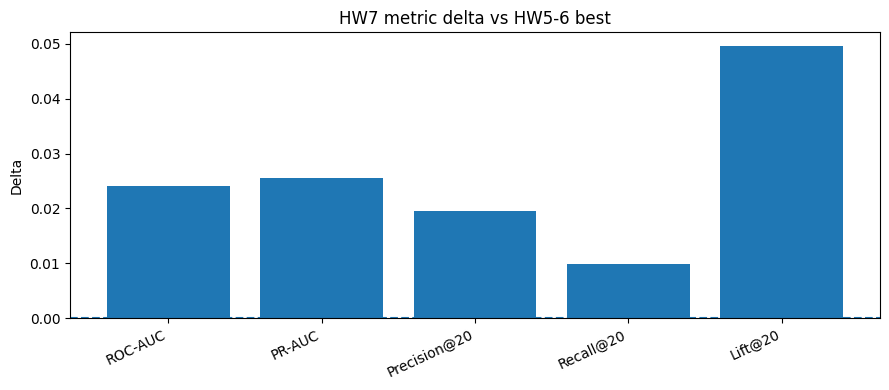

In [12]:
metric_diff = pd.DataFrame([
    {
        "metric": "quality_index",
        "HW5-6 best": hw56_result["quality_index"],
        "HW7 improved": raw_result["quality_index"],
        "delta": raw_result["quality_index"] - hw56_result["quality_index"],
    },
    {
        "metric": "ROC-AUC",
        "HW5-6 best": hw56_result["roc_auc"],
        "HW7 improved": raw_result["roc_auc"],
        "delta": raw_result["roc_auc"] - hw56_result["roc_auc"],
    },
    {
        "metric": "PR-AUC",
        "HW5-6 best": hw56_result["pr_auc"],
        "HW7 improved": raw_result["pr_auc"],
        "delta": raw_result["pr_auc"] - hw56_result["pr_auc"],
    },
    {
        "metric": "Brier",
        "HW5-6 best": hw56_result["brier"],
        "HW7 improved": raw_result["brier"],
        "delta": raw_result["brier"] - hw56_result["brier"],
    },
    {
        "metric": "Precision@20",
        "HW5-6 best": hw56_result["precision_at_20"],
        "HW7 improved": raw_result["precision_at_20"],
        "delta": raw_result["precision_at_20"] - hw56_result["precision_at_20"],
    },
    {
        "metric": "Recall@20",
        "HW5-6 best": hw56_result["recall_at_20"],
        "HW7 improved": raw_result["recall_at_20"],
        "delta": raw_result["recall_at_20"] - hw56_result["recall_at_20"],
    },
    {
        "metric": "Lift@20",
        "HW5-6 best": hw56_result["lift_at_20"],
        "HW7 improved": raw_result["lift_at_20"],
        "delta": raw_result["lift_at_20"] - hw56_result["lift_at_20"],
    },
])

display(metric_diff.style.format({"HW5-6 best": "{:.4f}", "HW7 improved": "{:.4f}", "delta": "{:+.4f}"}))
metric_diff.to_csv(TABLE_DIR / "hw7_metric_diff_vs_hw56.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 4))
plot_df = metric_diff[metric_diff["metric"].isin(["ROC-AUC", "PR-AUC", "Precision@20", "Recall@20", "Lift@20"])]
ax.bar(plot_df["metric"], plot_df["delta"])
ax.axhline(0, linestyle="--")
ax.set_title("HW7 metric delta vs HW5-6 best")
ax.set_ylabel("Delta")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "metric_delta_vs_hw56.png", dpi=160, bbox_inches="tight")
plt.show()

## 9. Постобработка предсказаний

Для MVP модель должна возвращать не только вероятность отмены. Revenue-менеджеру нужен приоритет действий.

Используются сущности:

```text
risk_score = P(is_canceled = 1)
risk_category = Low / Medium / High / Critical
expected_loss = risk_score × booking_value × deposit_loss_factor
business_priority_score = expected_loss
recommended_action = управленческое действие
```

`deposit_loss_factor` оставлен из ДЗ №5–6, потому что он исправляет важную бизнес-ошибку: высокая вероятность отмены для `Non Refund` не всегда означает высокий финансовый риск.

In [13]:
def deposit_loss_factor(deposit_type):
    mapping = {
        "No Deposit": 1.00,
        "Refundable": 0.80,
        "Non Refund": 0.05,
    }
    return mapping.get(deposit_type, 1.00)


def assign_risk_category(score):
    if score >= 0.80:
        return "Critical"
    if score >= 0.60:
        return "High"
    if score >= 0.30:
        return "Medium"
    return "Low"


def recommended_action(row):
    if row["deposit_type"] == "Non Refund":
        return "низкий финансовый приоритет: проверить оплату/условия удержания; учитывать в прогнозе загрузки"
    if row["risk_category"] in ["Critical", "High"] and row["deposit_type"] == "No Deposit":
        return "высокий приоритет: запросить подтверждение, предложить депозит/невозвратный тариф, учесть в overbooking"
    if row["risk_category"] in ["Critical", "High"] and row["deposit_type"] == "Refundable":
        return "средний/высокий приоритет: напоминание, уточнение намерения приехать, контроль срока бесплатной отмены"
    if row["risk_category"] == "Medium":
        return "мягкое напоминание или мониторинг без ручной эскалации"
    return "без дополнительных действий"

business_df = model_df.iloc[idx_test].copy()
business_df["booking_id"] = business_df.index + 1
business_df["risk_score"] = score_test_raw
business_df["risk_score_calibrated"] = score_test_calibrated
business_df["risk_category"] = business_df["risk_score"].apply(assign_risk_category)
business_df["deposit_loss_factor"] = business_df["deposit_type"].apply(deposit_loss_factor)
business_df["expected_loss"] = (
    business_df["risk_score"]
    * business_df["booking_value"].clip(lower=0)
    * business_df["deposit_loss_factor"]
)
business_df["business_priority_score"] = business_df["expected_loss"]
business_df["recommended_action"] = business_df.apply(recommended_action, axis=1)

top_by_risk = business_df.sort_values("risk_score", ascending=False).head(20)
top_by_business = business_df.sort_values("business_priority_score", ascending=False).head(20)

priority_compare = pd.DataFrame({
    "sorting": ["top by raw risk_score", "top by business_priority_score"],
    "non_refund_share": [
        (top_by_risk["deposit_type"] == "Non Refund").mean(),
        (top_by_business["deposit_type"] == "Non Refund").mean(),
    ],
    "no_deposit_share": [
        (top_by_risk["deposit_type"] == "No Deposit").mean(),
        (top_by_business["deposit_type"] == "No Deposit").mean(),
    ],
    "expected_loss_sum": [
        top_by_risk["expected_loss"].sum(),
        top_by_business["expected_loss"].sum(),
    ],
})

display(priority_compare.style.format({
    "non_refund_share": "{:.1%}",
    "no_deposit_share": "{:.1%}",
    "expected_loss_sum": "{:,.0f}",
}))
priority_compare.to_csv(TABLE_DIR / "hw7_priority_sorting_comparison.csv", index=False)

business_cols = [
    "booking_id", "hotel", "arrival_date", "deposit_type", "market_segment", "customer_type",
    "booking_value", "risk_score", "risk_category", "expected_loss", "business_priority_score",
    "recommended_action", "is_canceled",
]
top_priority_bookings = business_df.sort_values("business_priority_score", ascending=False).head(30)[business_cols]
display(top_priority_bookings)
top_priority_bookings.to_csv(TABLE_DIR / "hw7_top_business_priority_bookings.csv", index=False)

,sorting,non_refund_share,no_deposit_share,expected_loss_sum
0,top by raw risk_score,100.0%,0.0%,426
1,top by business_priority_score,0.0%,100.0%,"45,416"


,booking_id,hotel,arrival_date,deposit_type,market_segment,customer_type,booking_value,risk_score,risk_category,expected_loss,business_priority_score,recommended_action,is_canceled
112746,112747,Resort Hotel,2017-07-22,No Deposit,Online TA,Transient,2543.022,0.959882,Critical,2441.002177,2441.002177,"высокий приоритет: запросить подтверждение, пр...",1
111892,111893,Resort Hotel,2017-07-17,No Deposit,Online TA,Transient,2543.022,0.931234,Critical,2368.147767,2368.147767,"высокий приоритет: запросить подтверждение, пр...",1
118772,118773,Resort Hotel,2017-08-28,No Deposit,Online TA,Transient,2543.022,0.926433,Critical,2355.939990,2355.939990,"высокий приоритет: запросить подтверждение, пр...",1
112470,112471,Resort Hotel,2017-07-21,No Deposit,Online TA,Transient,2543.022,0.917867,Critical,2334.155582,2334.155582,"высокий приоритет: запросить подтверждение, пр...",1
115446,115447,Resort Hotel,2017-08-07,No Deposit,Online TA,Transient,2543.022,0.901574,Critical,2292.723149,2292.723149,"высокий приоритет: запросить подтверждение, пр...",1
118404,118405,Resort Hotel,2017-08-26,No Deposit,Online TA,Transient,2543.022,0.899968,Critical,2288.637428,2288.637428,"высокий приоритет: запросить подтверждение, пр...",1
111302,111303,Resort Hotel,2017-07-14,No Deposit,Online TA,Transient,2543.022,0.899756,Critical,2288.098364,2288.098364,"высокий приоритет: запросить подтверждение, пр...",1
114313,114314,Resort Hotel,2017-08-01,No Deposit,Online TA,Transient,2543.022,0.897766,Critical,2283.039862,2283.039862,"высокий приоритет: запросить подтверждение, пр...",1
115214,115215,City Hotel,2017-08-06,No Deposit,Online TA,Transient,2433.620,0.936476,Critical,2279.026715,2279.026715,"высокий приоритет: запросить подтверждение, пр...",1
103869,103870,Resort Hotel,2017-06-03,No Deposit,Online TA,Transient,2543.022,0.882893,Critical,2245.215956,2245.215956,"высокий приоритет: запросить подтверждение, пр...",1


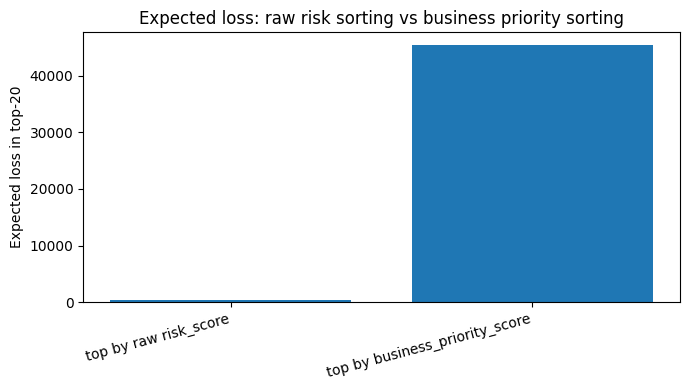

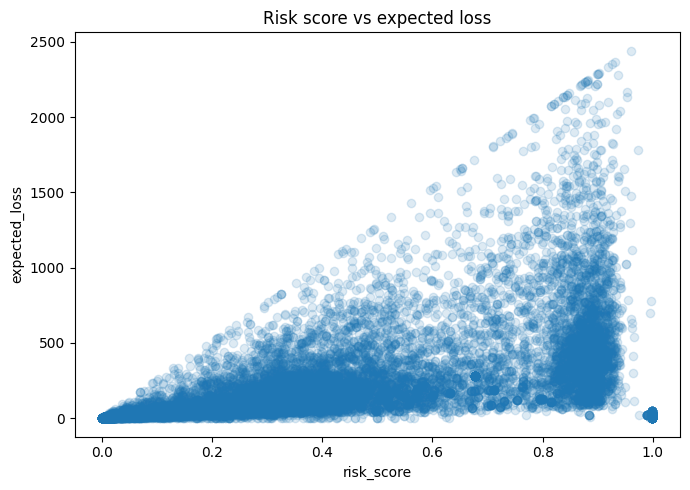

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(priority_compare["sorting"], priority_compare["expected_loss_sum"])
ax.set_title("Expected loss: raw risk sorting vs business priority sorting")
ax.set_ylabel("Expected loss in top-20")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "expected_loss_sorting_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(business_df["risk_score"], business_df["expected_loss"], alpha=0.15)
ax.set_title("Risk score vs expected loss")
ax.set_xlabel("risk_score")
ax.set_ylabel("expected_loss")
plt.tight_layout()
plt.savefig(FIG_DIR / "risk_score_vs_expected_loss.png", dpi=160, bbox_inches="tight")
plt.show()

## 10. Анализ ошибок

Проверяем ошибки не только в среднем, но и по сегментам. Для MVP важно понимать, где модель может быть рискованной в эксплуатации.

Используются:

- confusion matrix по validation-selected threshold;
- сегментные метрики по `hotel`, `deposit_type`, `market_segment`, `customer_type`;
- примеры false positive и false negative с высоким score.

,pred_0,pred_1
actual_0,5712,5121
actual_1,176,6873


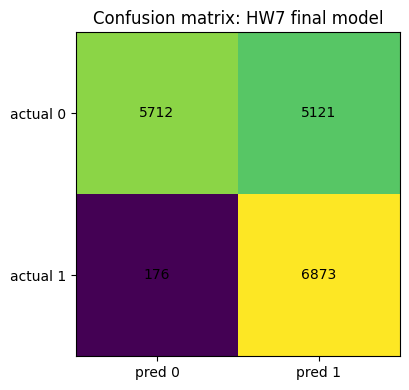

In [15]:
pred_test = (score_test_raw >= threshold_raw).astype(int)
cm = confusion_matrix(y_test, pred_test)
cm_df = pd.DataFrame(cm, index=["actual_0", "actual_1"], columns=["pred_0", "pred_1"])
display(cm_df)
cm_df.to_csv(TABLE_DIR / "hw7_confusion_matrix.csv")

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm)
ax.set_title("Confusion matrix: HW7 final model")
ax.set_xticks([0, 1])
ax.set_xticklabels(["pred 0", "pred 1"])
ax.set_yticks([0, 1])
ax.set_yticklabels(["actual 0", "actual 1"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center")
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

In [16]:
def segment_quality(df: pd.DataFrame, segment_col: str) -> pd.DataFrame:
    rows = []
    for value, part in df.groupby(segment_col, observed=False):
        if len(part) < 50:
            continue
        y_part = part["is_canceled"].astype(int)
        s_part = part["risk_score"]
        p20, r20, l20 = topk_metrics(y_part, s_part, 0.20)
        rows.append({
            "segment": segment_col,
            "value": value,
            "rows": len(part),
            "cancel_rate": y_part.mean(),
            "roc_auc": roc_auc_score(y_part, s_part) if y_part.nunique() > 1 else np.nan,
            "pr_auc": average_precision_score(y_part, s_part) if y_part.nunique() > 1 else np.nan,
            "precision_at_20": p20,
            "recall_at_20": r20,
            "lift_at_20": l20,
            "expected_loss_sum": part["expected_loss"].sum(),
        })
    return pd.DataFrame(rows).sort_values(["segment", "rows"], ascending=[True, False])

segment_tables = []
for col in ["hotel", "deposit_type", "market_segment", "customer_type"]:
    seg = segment_quality(business_df, col)
    segment_tables.append(seg)

segment_quality_df = pd.concat(segment_tables, ignore_index=True)
display(segment_quality_df.style.format({
    "cancel_rate": "{:.1%}",
    "roc_auc": "{:.4f}",
    "pr_auc": "{:.4f}",
    "precision_at_20": "{:.4f}",
    "recall_at_20": "{:.4f}",
    "lift_at_20": "{:.4f}",
    "expected_loss_sum": "{:,.0f}",
}))
segment_quality_df.to_csv(TABLE_DIR / "hw7_segment_quality.csv", index=False)

,segment,value,rows,cancel_rate,roc_auc,pr_auc,precision_at_20,recall_at_20,lift_at_20,expected_loss_sum
0,hotel,City Hotel,12010,40.5%,0.8714,0.8286,0.8668,0.4285,2.1424,"2,022,734"
1,hotel,Resort Hotel,5872,37.3%,0.9006,0.8271,0.8562,0.4594,2.2956,"1,781,331"
2,deposit_type,No Deposit,16538,34.5%,0.8486,0.6967,0.7358,0.4266,2.1326,"3,772,397"
3,deposit_type,Non Refund,1325,99.9%,1.0000,1.0000,1.0000,0.2002,1.0008,"23,106"
4,market_segment,Online TA,10820,42.7%,0.7981,0.7045,0.7320,0.3430,1.7150,"3,078,985"
5,market_segment,Offline TA/TO,2833,33.5%,0.9832,0.9672,0.9947,0.5949,2.9726,"248,943"
6,market_segment,Direct,2117,18.9%,0.8124,0.5071,0.4835,0.5125,2.5589,"378,017"
7,market_segment,Groups,1497,61.8%,0.9903,0.9943,1.0000,0.3243,1.6184,"56,030"
8,market_segment,Corporate,475,27.8%,0.9325,0.8852,0.9158,0.6591,3.2955,"38,540"
9,market_segment,Complementary,85,11.8%,0.6893,0.2366,0.2353,0.4000,2.0000,82


In [17]:
error_df = business_df.copy()
error_df["pred"] = pred_test
error_df["error_type"] = np.select(
    [
        (error_df["is_canceled"] == 1) & (error_df["pred"] == 1),
        (error_df["is_canceled"] == 0) & (error_df["pred"] == 0),
        (error_df["is_canceled"] == 0) & (error_df["pred"] == 1),
        (error_df["is_canceled"] == 1) & (error_df["pred"] == 0),
    ],
    ["TP", "TN", "FP", "FN"],
    default="unknown",
)

error_by_segment = (
    error_df
    .groupby(["hotel", "deposit_type", "error_type"], observed=False)
    .size()
    .reset_index(name="rows")
)
error_by_segment["share_in_error_type"] = error_by_segment["rows"] / error_by_segment.groupby("error_type")["rows"].transform("sum")
display(error_by_segment.sort_values(["error_type", "rows"], ascending=[True, False]).head(30))
error_by_segment.to_csv(TABLE_DIR / "hw7_error_by_segment.csv", index=False)

false_positives = error_df[error_df["error_type"] == "FP"].sort_values("risk_score", ascending=False).head(15)[business_cols + ["pred", "error_type"]]
false_negatives = error_df[error_df["error_type"] == "FN"].sort_values("risk_score", ascending=True).head(15)[business_cols + ["pred", "error_type"]]

print("High-confidence false positives")
display(false_positives)
print("Low-score false negatives")
display(false_negatives)

false_positives.to_csv(TABLE_DIR / "hw7_false_positives_examples.csv", index=False)
false_negatives.to_csv(TABLE_DIR / "hw7_false_negatives_examples.csv", index=False)

,hotel,deposit_type,error_type,rows,share_in_error_type
0,City Hotel,No Deposit,FN,104,0.590909
6,Resort Hotel,No Deposit,FN,72,0.409091
1,City Hotel,No Deposit,FP,3882,0.758055
7,Resort Hotel,No Deposit,FP,1238,0.241750
10,Resort Hotel,Non Refund,FP,1,0.000195
2,City Hotel,No Deposit,TN,3269,0.572304
8,Resort Hotel,No Deposit,TN,2443,0.427696
3,City Hotel,No Deposit,TP,3518,0.511858
9,Resort Hotel,No Deposit,TP,2012,0.292740
4,City Hotel,Non Refund,TP,1228,0.178670


High-confidence false positives


,booking_id,hotel,arrival_date,deposit_type,market_segment,customer_type,booking_value,risk_score,risk_category,expected_loss,business_priority_score,recommended_action,is_canceled,pred,error_type
105126,105127,Resort Hotel,2017-06-09,No Deposit,Direct,Transient,780.00,0.996613,Critical,777.358514,777.358514,"высокий приоритет: запросить подтверждение, пр...",0,1,FP
105465,105466,City Hotel,2017-06-11,No Deposit,Online TA,Transient,763.20,0.943049,Critical,719.735149,719.735149,"высокий приоритет: запросить подтверждение, пр...",0,1,FP
103604,103605,City Hotel,2017-06-02,No Deposit,Online TA,Transient,648.00,0.938958,Critical,608.444515,608.444515,"высокий приоритет: запросить подтверждение, пр...",0,1,FP
117189,117190,City Hotel,2017-08-18,No Deposit,Online TA,Transient,375.30,0.938838,Critical,352.345736,352.345736,"высокий приоритет: запросить подтверждение, пр...",0,1,FP
114966,114967,Resort Hotel,2017-08-05,No Deposit,Online TA,Transient,1680.00,0.936913,Critical,1574.013670,1574.013670,"высокий приоритет: запросить подтверждение, пр...",0,1,FP
114859,114860,City Hotel,2017-08-04,No Deposit,Online TA,Transient,270.00,0.936504,Critical,252.856138,252.856138,"высокий приоритет: запросить подтверждение, пр...",0,1,FP
108434,108435,City Hotel,2017-06-28,No Deposit,Online TA,Transient,653.38,0.935922,Critical,611.513038,611.513038,"высокий приоритет: запросить подтверждение, пр...",0,1,FP
107463,107464,City Hotel,2017-06-22,No Deposit,Online TA,Transient,540.00,0.934639,Critical,504.704958,504.704958,"высокий приоритет: запросить подтверждение, пр...",0,1,FP
108028,108029,City Hotel,2017-06-26,No Deposit,Online TA,Transient,579.00,0.934000,Critical,540.786063,540.786063,"высокий приоритет: запросить подтверждение, пр...",0,1,FP
109103,109104,City Hotel,2017-07-01,No Deposit,Online TA,Transient,198.00,0.933689,Critical,184.870418,184.870418,"высокий приоритет: запросить подтверждение, пр...",0,1,FP


Low-score false negatives


,booking_id,hotel,arrival_date,deposit_type,market_segment,customer_type,booking_value,risk_score,risk_category,expected_loss,business_priority_score,recommended_action,is_canceled,pred,error_type
115603,115604,Resort Hotel,2017-08-09,No Deposit,Offline TA/TO,Contract,674.25,0.006437,Low,4.339942,4.339942,без дополнительных действий,1,0,FN
111784,111785,City Hotel,2017-07-16,No Deposit,Direct,Transient,270.00,0.016522,Low,4.461037,4.461037,без дополнительных действий,1,0,FN
103633,103634,Resort Hotel,2017-06-02,No Deposit,Online TA,Transient,210.00,0.023668,Low,4.970301,4.970301,без дополнительных действий,1,0,FN
103702,103703,Resort Hotel,2017-06-02,No Deposit,Online TA,Transient,210.00,0.023668,Low,4.970301,4.970301,без дополнительных действий,1,0,FN
103700,103701,Resort Hotel,2017-06-02,No Deposit,Online TA,Transient,210.00,0.023668,Low,4.970301,4.970301,без дополнительных действий,1,0,FN
103691,103692,Resort Hotel,2017-06-02,No Deposit,Online TA,Transient,210.00,0.023668,Low,4.970301,4.970301,без дополнительных действий,1,0,FN
103662,103663,Resort Hotel,2017-06-02,No Deposit,Online TA,Transient,210.00,0.023668,Low,4.970301,4.970301,без дополнительных действий,1,0,FN
103632,103633,Resort Hotel,2017-06-02,No Deposit,Online TA,Transient,210.00,0.023668,Low,4.970301,4.970301,без дополнительных действий,1,0,FN
105756,105757,City Hotel,2017-06-13,No Deposit,Offline TA/TO,Transient,99.00,0.027271,Low,2.699856,2.699856,без дополнительных действий,1,0,FN
104603,104604,Resort Hotel,2017-06-07,No Deposit,Online TA,Transient,560.00,0.028426,Low,15.918670,15.918670,без дополнительных действий,1,0,FN


## 11. ROC и Precision-Recall curves

Кривые нужны, чтобы видеть не только одну точку threshold, а весь trade-off. Для продукта важнее PR-curve и top-k метрики, потому что менеджер работает с верхним списком бронирований.

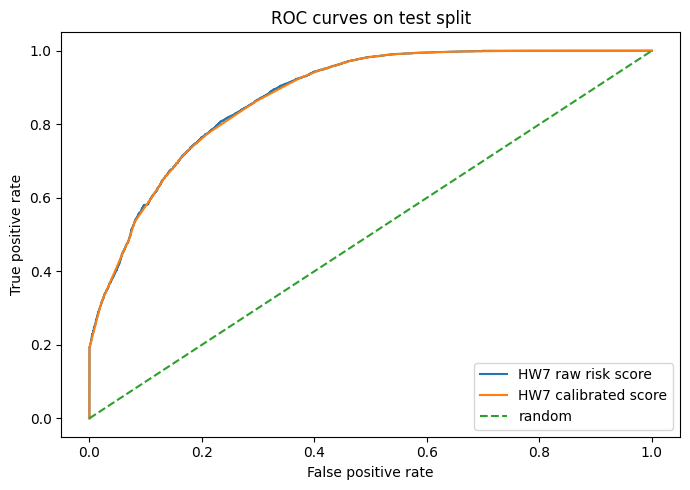

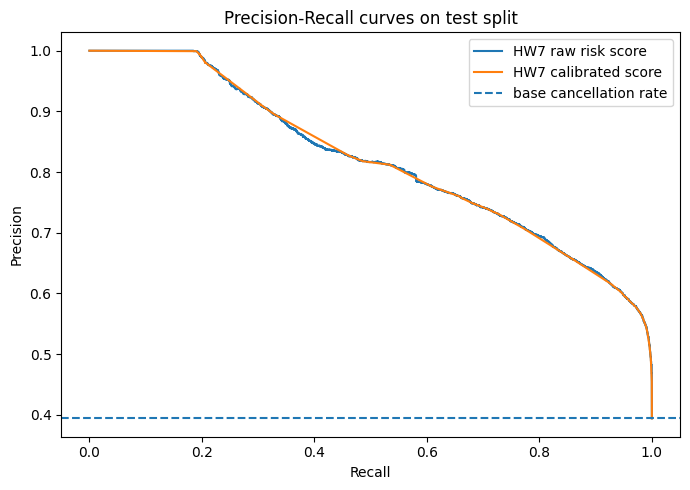

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, score in {
    "HW7 raw risk score": score_test_raw,
    "HW7 calibrated score": score_test_calibrated,
}.items():
    fpr, tpr, _ = roc_curve(y_test, score)
    ax.plot(fpr, tpr, label=name)
ax.plot([0, 1], [0, 1], linestyle="--", label="random")
ax.set_title("ROC curves on test split")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "roc_curves.png", dpi=160, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
for name, score in {
    "HW7 raw risk score": score_test_raw,
    "HW7 calibrated score": score_test_calibrated,
}.items():
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, score)
    ax.plot(recall_curve, precision_curve, label=name)
ax.axhline(y_test.mean(), linestyle="--", label="base cancellation rate")
ax.set_title("Precision-Recall curves on test split")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "precision_recall_curves.png", dpi=160, bbox_inches="tight")
plt.show()

## 12. Финальный вывод

Финальная модель ДЗ №7 — `HW7 LightGBM FE + train-only encoding`.

Ключевые результаты test split:

```text
quality_index ≈ 0.7816
ROC-AUC       ≈ 0.8771
PR-AUC        ≈ 0.8197
Brier         ≈ 0.1427
Precision@20  ≈ 0.8367
Recall@20     ≈ 0.4246
Lift@20       ≈ 2.1226
```

По сравнению с лучшей моделью ДЗ №5–6 улучшились все основные метрики:

```text
quality_index: +0.0209
ROC-AUC:       +0.0241
PR-AUC:        +0.0255
Brier:         -0.0180  # меньше — лучше
Precision@20:  +0.0195
Recall@20:     +0.0099
Lift@20:       +0.0496
```

Главная причина улучшения — не замена модели сама по себе, а расширение данных: календарные и interaction-признаки плюс train-only encoding для high-cardinality operational-сигналов. Это повышает качество ранжирования top-list без прямого leakage


In [21]:
# Сохранение финальных таблиц со score для возможной упаковки MVP.
score_export = business_df[[
    "booking_id", "risk_score", "risk_score_calibrated", "risk_category",
    "booking_value", "deposit_type", "deposit_loss_factor", "expected_loss",
    "business_priority_score", "recommended_action", "is_canceled",
]].copy()
score_export.to_csv(TABLE_DIR / "hw7_test_predictions_for_mvp.csv", index=False)

final_summary = {
    "final_model": raw_result["model"],
    "selected_threshold": raw_result["threshold"],
    "metrics": {k: raw_result[k] for k in [
        "quality_index", "roc_auc", "pr_auc", "brier", "precision_at_20", "recall_at_20", "lift_at_20",
    ]},
    "best_params": raw_result["best_params"],
    "output_tables": {
        "leaderboard": str(TABLE_DIR / "hw7_model_improvement_leaderboard.csv"),
        "metric_diff": str(TABLE_DIR / "hw7_metric_diff_vs_hw56.csv"),
        "top_priority_bookings": str(TABLE_DIR / "hw7_top_business_priority_bookings.csv"),
        "test_predictions_for_mvp": str(TABLE_DIR / "hw7_test_predictions_for_mvp.csv"),
    },
}

